GP

In [16]:
import numpy as np
import json
results = []
grouped = {}
avg_by_idx = {}

seeds = [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
idxs = [0, 1, 2]

avg_by_idx = {}

for idx in idxs:
    mae_all = []
    rmse_all = []
    r2_all = []

    for seed in seeds:
        gp_path = f'./GP_AL_results_seed_{seed}_{idx}.json'
        with open(gp_path, 'r') as f:
            data = json.load(f)

        # 每个都是长度21的序列
        mae_all.append(data['mae'])
        rmse_all.append(data['rmse'])
        r2_all.append(data['r2'])

    mae_all = np.array(mae_all)    # shape: [n_seed, 21]
    rmse_all = np.array(rmse_all)  # shape: [n_seed, 21]
    r2_all = np.array(r2_all)      # shape: [n_seed, 21]

    avg_by_idx[idx] = {
        'mae_mean': mae_all.mean(axis=0).tolist(),     # 长度21
        'mae_std': mae_all.std(axis=0).tolist(),       # 长度21
        'rmse_mean': rmse_all.mean(axis=0).tolist(),   # 长度21
        'rmse_std': rmse_all.std(axis=0).tolist(),     # 长度21
        'r2_mean': r2_all.mean(axis=0).tolist(),       # 长度21
        'r2_std': r2_all.std(axis=0).tolist(),         # 长度21
    }

# 例子：看 idx=0 的 mae 平均曲线（21步）
print(len(avg_by_idx[0]['mae_mean']))  # 21
print(avg_by_idx[0]['mae_mean'])


summary_json_path = '../result_plot/GP_metrics_summary.json'
with open(summary_json_path, 'w', encoding='utf-8') as f:
    json.dump(avg_by_idx, f, ensure_ascii=False, indent=2)

21
[38.15475363523498, 23.026815188058812, 20.513235069433613, 20.62464991895871, 16.499667417616042, 16.652022893046826, 16.135819368923944, 13.567099140392054, 13.593935157181225, 11.980218707389493, 12.041970653401552, 11.338711598452264, 10.669859497664577, 10.236097858439024, 9.529764164783732, 9.119386774449449, 8.677501180355316, 8.608918015231946, 8.032606278206627, 7.732203882547895, 7.407661705514521]


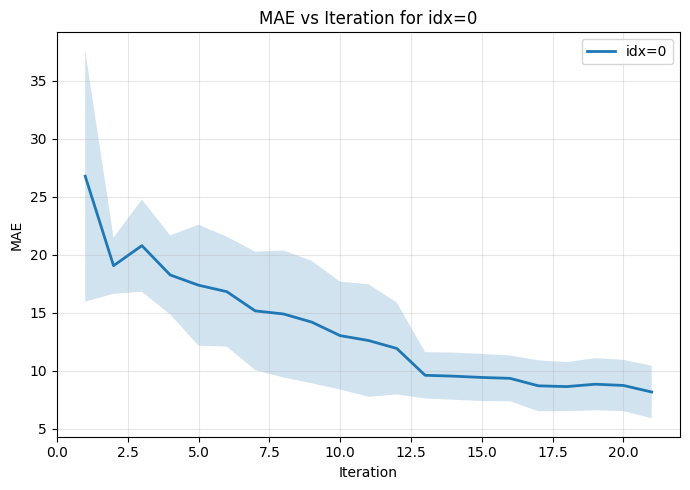

In [10]:
import matplotlib.pyplot as plt

def plot_metric_by_idx(
    avg_by_idx,
    metric='mae',          # 你自己改：'mae' / 'rmse' / 'r2'
    idx=0,         # 你自己改：例如 [0,1,2]；None 表示全部
    title=None,
    xlabel='Iteration',
    ylabel=None,
    figsize=(7, 5),
):

    n_steps = len(avg_by_idx[idx][f'{metric}_mean'])
    x = np.arange(1, n_steps + 1)

    plt.figure(figsize=figsize)

    mean = np.array(avg_by_idx[idx][f'{metric}_mean'])
    std = np.array(avg_by_idx[idx][f'{metric}_std'])

    plt.plot(x, mean, label=f'idx={idx}', linewidth=2)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel if ylabel else metric.upper())
    plt.title(title if title else f'{metric.upper()} vs Iteration')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_metric_by_idx(avg_by_idx, metric='mae', idx=0, title='MAE vs Iteration for idx=0', ylabel='MAE')

AL

In [14]:
import numpy as np
import json
from pathlib import Path
results = []
grouped = {}
avg_by_idx = {}

seeds = [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
idxs = [0, 1, 2]

avg_by_idx = {}


for idx in idxs:
    mae_all = []                        
    rmse_all = []
    r2_all = []

    for seed in seeds:
        base_dir = Path(f'./{idx}/{seed}')
        pattern = 'TreeBasedRegressor_Representativity_self_metrics_*.json'
        file = sorted(base_dir.glob(pattern))
        if not file:
            print(f"No files found for idx={idx}, seed={seed}")
            continue

        with open(file[0], 'r') as f:
            data = json.load(f)

        method_key = next(iter(data.keys()))  # 获取第一个键
        steps = data[method_key]

        mae_seq = [np.nan if s.get('mae') is None else float(s.get('mae')) for s in steps]
        rmse_seq = [np.nan if s.get('rmse') is None else float(s.get('rmse')) for s in steps]
        r2_seq = [np.nan if s.get('r2') is None else float(s.get('r2')) for s in steps]


        # 每个都是长度21的序列
        mae_all.append(mae_seq)
        rmse_all.append(rmse_seq)
        r2_all.append(r2_seq)

    mae_all = np.array(mae_all, dtype=float)    # [n_seed, 21]
    rmse_all = np.array(rmse_all, dtype=float)  # [n_seed, 21]
    r2_all = np.array(r2_all, dtype=float)      # [n_seed, 21]

    avg_by_idx[idx] = {
        'mae_mean': np.nanmean(mae_all, axis=0).tolist(),
        'mae_std': np.nanstd(mae_all, axis=0).tolist(),
        'rmse_mean': np.nanmean(rmse_all, axis=0).tolist(),
        'rmse_std': np.nanstd(rmse_all, axis=0).tolist(),
        'r2_mean': np.nanmean(r2_all, axis=0).tolist(),
        'r2_std': np.nanstd(r2_all, axis=0).tolist(),
    }

# 例子：看 idx=0 的 mae 平均曲线（21步）
print(len(avg_by_idx[0]['mae_mean']))  # 21
print(avg_by_idx[0]['mae_mean'])


summary_json_path = './AL_metrics_summary.json'
with open(summary_json_path, 'w', encoding='utf-8') as f:
    json.dump(avg_by_idx, f, ensure_ascii=False, indent=2)


21
[19.80141383644395, 19.760834600678095, 19.612900170272827, 20.04304142695326, 16.87131627025014, 15.545963259052325, 15.234949707548381, 17.149825930750488, 12.62686938904796, 12.960386580695594, 12.094296390163892, 11.196319183382233, 11.704594594025565, 9.803398174205563, 9.300384243157364, 9.349528679887918, 8.520890081993949, 7.912443132168077, 8.69292262725549, 7.077274237440439, 6.391196650018104]


QBC


In [2]:
import numpy as np
import json
results = []
grouped = {}
avg_by_idx = {}

seeds = [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
idxs = [0, 1, 2]

avg_by_idx = {}

for idx in idxs:
    mae_all = []
    rmse_all = []
    r2_all = []

    for seed in seeds:
        gp_path = f'./QBC_AL_PAN_results_seed_{seed}_{idx}.json'
        with open(gp_path, 'r') as f:
            data = json.load(f)

        # 每个都是长度21的序列
        mae_all.append(data['mae'])
        rmse_all.append(data['rmse'])
        r2_all.append(data['r2'])

    mae_all = np.array(mae_all)    # shape: [n_seed, 21]
    rmse_all = np.array(rmse_all)  # shape: [n_seed, 21]
    r2_all = np.array(r2_all)      # shape: [n_seed, 21]

    avg_by_idx[idx] = {
        'mae_mean': mae_all.mean(axis=0).tolist(),     # 长度21
        'mae_std': mae_all.std(axis=0).tolist(),       # 长度21
        'rmse_mean': rmse_all.mean(axis=0).tolist(),   # 长度21
        'rmse_std': rmse_all.std(axis=0).tolist(),     # 长度21
        'r2_mean': r2_all.mean(axis=0).tolist(),       # 长度21
        'r2_std': r2_all.std(axis=0).tolist(),         # 长度21
    }

# 例子：看 idx=0 的 mae 平均曲线（21步）
print(len(avg_by_idx[0]['mae_mean']))  # 21
print(avg_by_idx[0]['mae_mean'])


summary_json_path = '../result_plot/QBC_metrics_summary.json'
with open(summary_json_path, 'w', encoding='utf-8') as f:
    json.dump(avg_by_idx, f, ensure_ascii=False, indent=2)

21
[20.694807389038658, 19.359810539206414, 20.121985822732277, 19.943068467029136, 19.328700636620958, 19.578309783396563, 19.641815472897864, 19.2774456985805, 19.32047762832674, 19.247577237763895, 19.28686376269645, 19.272244190259446, 20.00568098650971, 19.443954358067835, 19.083499991076017, 19.219388064410268, 19.22930296722583, 19.026908989425316, 19.260703664649114, 19.31846337363981, 19.208672465748283]


qbc alt

In [1]:
import numpy as np
import json
results = []
grouped = {}
avg_by_idx = {}

seeds = [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
idxs = [0, 1, 2]

avg_by_idx = {}

for idx in idxs:
    mae_all = []
    rmse_all = []
    r2_all = []

    for seed in seeds:
        gp_path = f'./QBC_ALT_AL_PAN_results_seed_{seed}_{idx}.json'
        with open(gp_path, 'r') as f:
            data = json.load(f)

        # 每个都是长度21的序列
        mae_all.append(data['mae'])
        rmse_all.append(data['rmse'])
        r2_all.append(data['r2'])

    mae_all = np.array(mae_all)    # shape: [n_seed, 21]
    rmse_all = np.array(rmse_all)  # shape: [n_seed, 21]
    r2_all = np.array(r2_all)      # shape: [n_seed, 21]

    avg_by_idx[idx] = {
        'mae_mean': mae_all.mean(axis=0).tolist(),     # 长度21
        'mae_std': mae_all.std(axis=0).tolist(),       # 长度21
        'rmse_mean': rmse_all.mean(axis=0).tolist(),   # 长度21
        'rmse_std': rmse_all.std(axis=0).tolist(),     # 长度21
        'r2_mean': r2_all.mean(axis=0).tolist(),       # 长度21
        'r2_std': r2_all.std(axis=0).tolist(),         # 长度21
    }

# 例子：看 idx=0 的 mae 平均曲线（21步）
print(len(avg_by_idx[0]['mae_mean']))  # 21
print(avg_by_idx[0]['mae_mean'])


summary_json_path = '../result_plot/QBC_ALT_metrics_summary.json'
with open(summary_json_path, 'w', encoding='utf-8') as f:
    json.dump(avg_by_idx, f, ensure_ascii=False, indent=2)

21
[20.694807389038658, 22.60803045090092, 22.175481815295477, 21.60084333531046, 19.939417923408087, 19.35282337160678, 19.655604568202925, 19.711747921250282, 19.77134419644568, 19.09200389216591, 18.720233900903775, 18.813776753268154, 19.363413185554855, 18.7034490979352, 18.88959907097188, 18.729073620208602, 18.648025337830212, 19.152693735005503, 19.098705936600183, 19.061579640685405, 19.07249612926023]
